In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image

In [9]:
df=pd.read_csv("/kaggle/input/competitions/byu-locating-bacterial-flagellar-motors-2025/train_labels.csv")
print(df.columns)
print(df.head(10))
print(df.shape)

Index(['row_id', 'tomo_id', 'Motor axis 0', 'Motor axis 1', 'Motor axis 2',
       'Array shape (axis 0)', 'Array shape (axis 1)', 'Array shape (axis 2)',
       'Voxel spacing', 'Number of motors'],
      dtype='object')
   row_id      tomo_id  Motor axis 0  Motor axis 1  Motor axis 2  \
0       0  tomo_003acc          -1.0          -1.0          -1.0   
1       1  tomo_00e047         169.0         546.0         603.0   
2       2  tomo_00e463         235.0         403.0         137.0   
3       3  tomo_00e463         243.0         363.0         153.0   
4       4  tomo_00e463         222.0         379.0         144.0   
5       5  tomo_00e463         225.0         262.0         628.0   
6       6  tomo_00e463         225.0         241.0         643.0   
7       7  tomo_00e463         231.0         289.0         632.0   
8       8  tomo_01a877         147.0         638.0         286.0   
9       9  tomo_02862f         101.0         351.0         120.0   

   Array shape (axis 0)  Arra

In [10]:
print("Total tomograms:", df['tomo_id'].nunique())
print("Tomograms with no motor:", (df['Number of motors'] == 0).sum())
print("Tomograms with motors:", (df['Number of motors'] > 0).sum())
print("\nMotor count distribution:")
print(df['Number of motors'].value_counts())

Total tomograms: 648
Tomograms with no motor: 286
Tomograms with motors: 451

Motor count distribution:
Number of motors
1     313
0     286
2      56
4      36
6      18
3      18
10     10
Name: count, dtype: int64


In [19]:
# Pick a tomogram with 1 motor
sample = df[df['Number of motors'] == 1].iloc[0]
tomo_id = sample['tomo_id']
motor_z = int(sample['Motor axis 0'])
print(tomo_id, motor_z, sample)



tomo_00e047 169 row_id                            1
tomo_id                 tomo_00e047
Motor axis 0                  169.0
Motor axis 1                  546.0
Motor axis 2                  603.0
Array shape (axis 0)            300
Array shape (axis 1)            959
Array shape (axis 2)            928
Voxel spacing                  15.6
Number of motors                  1
Name: 1, dtype: object


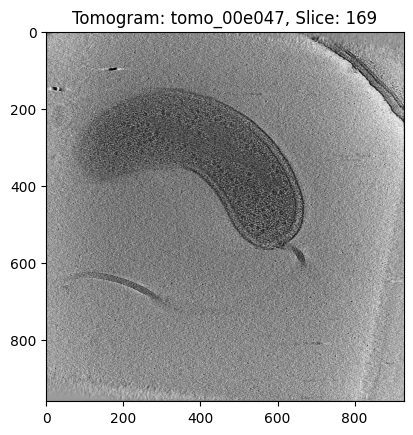

In [21]:
# Load that specific slice
slice_path = "/kaggle/input/competitions/byu-locating-bacterial-flagellar-motors-2025/train/tomo_00e047/slice_0169.jpg"
img = Image.open(slice_path)
plt.imshow(img, cmap='gray')
plt.title(f'Tomogram: {tomo_id}, Slice: {motor_z}')
plt.show()

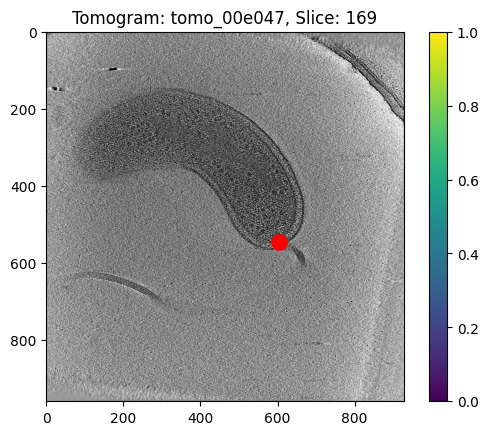

In [23]:
motor_y = int(sample['Motor axis 1'])
motor_x = int(sample['Motor axis 2'])

plt.imshow(img, cmap='gray')
plt.scatter(motor_x, motor_y, c='red', s=100, marker='o', linewidths=2)
plt.title(f'Tomogram: {tomo_id}, Slice: {motor_z}')
plt.colorbar()
plt.show()